# Project 5: Customer Segmentation with Clustering 🛍️

**Project Objective:** To use unsupervised machine learning to identify distinct groups of customers within a mall's dataset. By segmenting customers based on multiple dimensions (income, age, spending habits), we can provide rich, actionable insights to the marketing team for highly targeted campaigns.



### Step 1: Setup - Importing Libraries and Loading Data

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.cluster.hierarchy as sch

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Set plot style
sns.set_style('whitegrid')

In [ ]:
# Load the dataset from the user-provided file
!git clone "https://github.com/HarshvardhanSingh-13/Datasets"

fatal: destination path 'Datasets' already exists and is not an empty directory.


In [156]:
df = pd.read_csv('./Datasets/Mall Dataset/Mall_Customers.csv')

print("Dataset loaded successfully.")
print(f"Data shape: {df.shape}")
df.head()

Dataset loaded successfully.
Data shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [157]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


### Step 2: In-Depth Exploratory Data Analysis (EDA)
Before clustering, we must understand the features and their relationships to find the most promising dimensions for segmentation.

In [158]:
# Basic info and statistics
print("Dataset Info:")
df.info()

# Drop the CustomerID as it's just an identifier and not useful for clustering
df.drop('CustomerID', axis=1, inplace=True)

print("\nDescriptive Statistics:")
print(df.describe())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB

Descriptive Statistics:
              Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000          200.000000              200.000000
mean    38.850000           60.560000               50.200000
std     13.969007           26.264721               25.823522
min     18.000000           15.000000                1.000000
25%     28.750000           41.500000               34.750000
50%     36.000000           61.500000               50.000000
75%     49.000000           78.

####  Exploring Gender vs. Spending Score:   


Analyze the relationship between 'Gender' and 'Spending Score (1-100)' to see if gender plays a significant role in spending habits. Visualizations and summary statistics would be helpful here.

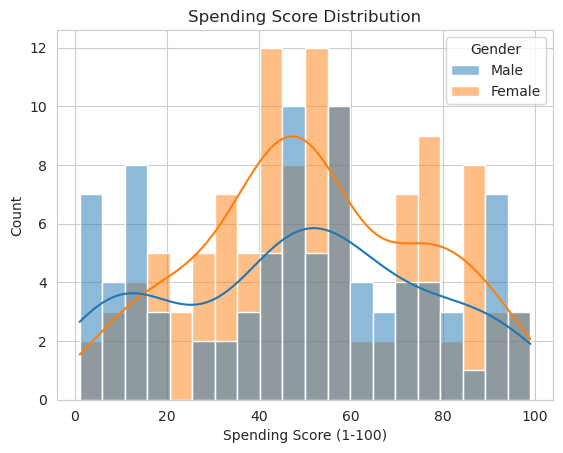

In [105]:
sns.histplot(data=df, x='Spending Score (1-100)', kde=True, bins=20, hue='Gender').set_title('Spending Score Distribution')

plt.show()

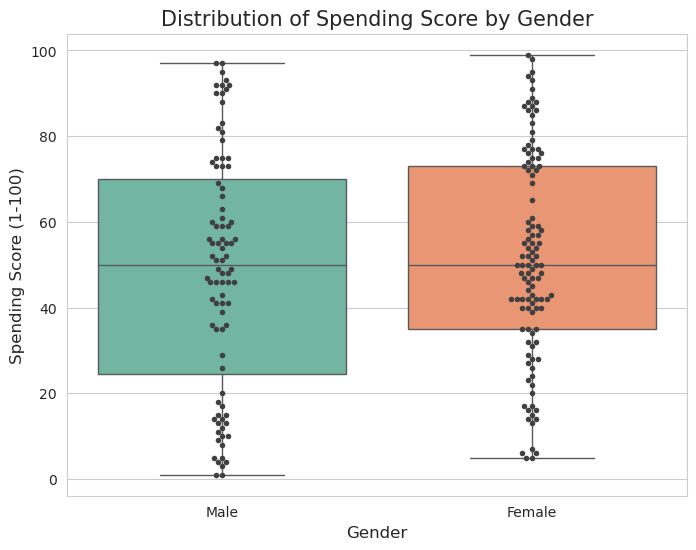

In [99]:
plt.figure(figsize=(8, 6))
plot = sns.boxplot(
    data=df, 
    x='Gender', 
    y='Spending Score (1-100)', 
    palette='Set2',
    hue='Gender',      
    legend=False       
)

sns.swarmplot(data=df, x='Gender', y='Spending Score (1-100)', color=".25", size=4)


plt.title('Distribution of Spending Score by Gender', fontsize=15)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)

plt.show()

### Insights
- Spending of both genders apears same with the given dataset

## **Apply Feature Engineering for Clustering:**
- Create a new feature using existing data (Feature Engineering). Then, explore if clustering can be effectively performed using this newly engineered feature in combination with one or more existing features. Document the feature engineering process, the chosen features for clustering, the determination of the optimal number of clusters (e.g., using the Elbow Method), and the resulting cluster visualization and interpretation.

### Feature engineering
+ Creating a new attribute spending to income ratio (spending_income_ratio)
   

In [159]:
df['spending_income_ratio'] = df['Spending Score (1-100)']/df['Annual Income (k$)']
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Gender                  200 non-null    str    
 1   Age                     200 non-null    int64  
 2   Annual Income (k$)      200 non-null    int64  
 3   Spending Score (1-100)  200 non-null    int64  
 4   spending_income_ratio   200 non-null    float64
dtypes: float64(1), int64(3), str(1)
memory usage: 7.9 KB


In [161]:
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer([('num_scaler', StandardScaler(), ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'spending_income_ratio'])], remainder='passthrough')
np_scaled = ct.fit_transform(df)
df_scaled = pd.DataFrame(np_scaled, columns=ct.get_feature_names_out())
# 3. Clean up the prefixes (e.g., 'scaler__Age' -> 'Age')
df_scaled.columns = [c.split('__')[-1] for c in df_scaled.columns]


In [163]:
df_scaled.head()

,Age,Annual Income (k$),Spending Score (1-100),spending_income_ratio,Gender
0,-1.424569,-1.738999,-0.434801,1.577244,Male
1,-1.281035,-1.738999,1.195704,4.46096,Male
2,-1.352802,-1.70083,-1.715913,-0.714279,Female
3,-1.137502,-1.70083,1.040418,3.855894,Female
4,-0.563369,-1.66266,-0.39598,1.322799,Female


In [ ]:
#X1_scaled['Spending Score (1-100)'] = pd.to_numeric(X1_scaled['Spending Score (1-100)'], errors='coerce')
#X1_scaled['Annual Income (k$)'] = pd.to_numeric(X1_scaled['Annual Income (k$)'], errors='coerce')
#X1_scaled['Age'] = pd.to_numeric(X1_scaled['Age'], errors='coerce')


#### Clustering

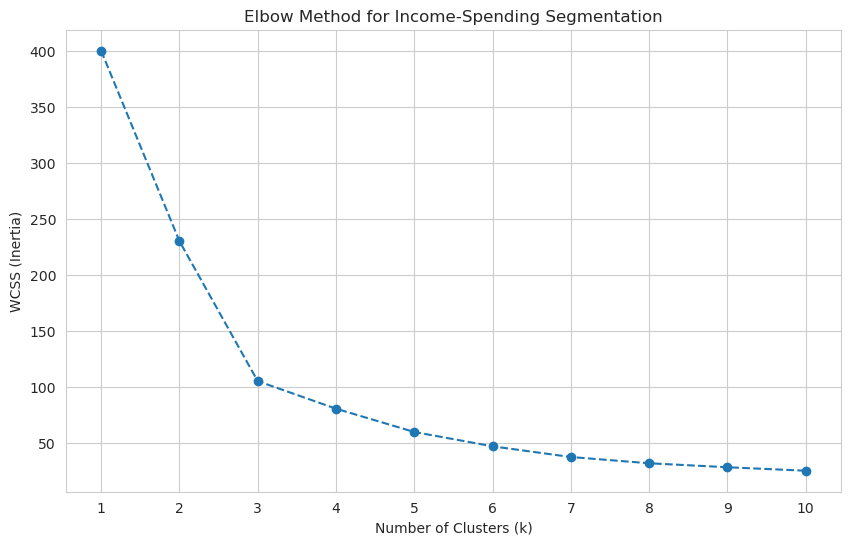

In [164]:
# 1. Select and scale the features
X1 = df_scaled[['Age', 'spending_income_ratio']]

# 2. Implement the Elbow Method
wcss1 = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X1)
    wcss1.append(kmeans.inertia_)

# 3. Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss1, marker='o', linestyle='--')
plt.title('Elbow Method for Income-Spending Segmentation')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.show()

**Observation:** The "elbow" of the curve is clearly at **k=5**. The WCSS decreases sharply until k=5, and then the rate of decrease flattens out. This confirms our visual intuition from the scatter plot!

In [165]:
# Build and fit the final model
kmeans1 = KMeans(n_clusters=3, init='k-means++', random_state=56, n_init=10)
df['Income_Cluster'] = kmeans1.fit_predict(X1)

#### 3.1 Visualizing and Interpreting the Income-Based Segments

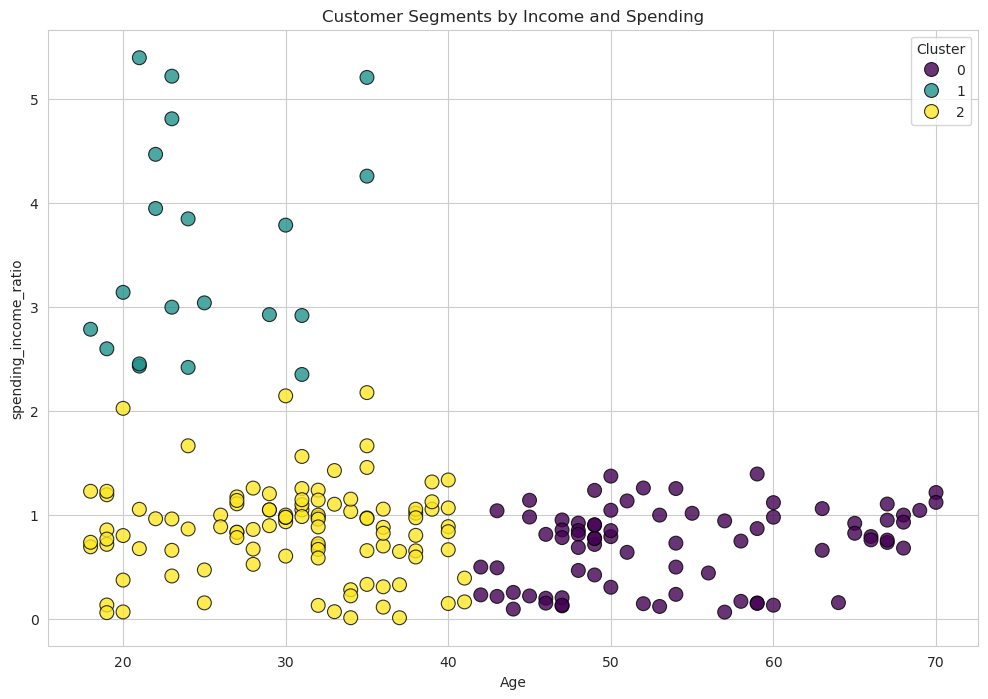

In [171]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='Age', y='spending_income_ratio',
                hue='Income_Cluster', palette='viridis', s=100, alpha=0.8, edgecolor='black')
plt.title('Customer Segments by Income and Spending')
plt.legend(title='Cluster')
plt.show()

In [172]:
# Quantitative Persona Analysis
cluster_profiles1 = df.groupby('Income_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'spending_income_ratio']].mean().round(2)
cluster_profiles1['Size'] = df['Income_Cluster'].value_counts()
print("--- Income-Based Cluster Profiles ---")
cluster_profiles1

--- Income-Based Cluster Profiles ---


,Age,Annual Income (k$),Spending Score (1-100),spending_income_ratio,Size
Income_Cluster,,,,,
0,54.04,57.49,36.18,0.70,76
1,24.85,23.00,77.55,3.55,20
2,30.44,70.03,55.18,0.86,104


##### Conclusion
1. Age groups 30-40 are high income low spenders
2. Age groups 20-30,30-40 are a mix of high income low spenders and low income high spenders
3. Age group 40 above are high income low spenders
